In [11]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path(r"C:\Project\Prediksi Pencemaran Udara di Jakarta\dataset")

excel_paths = sorted(DATA_DIR.glob('*.xls'))

print("Cek struktur kolom dataset ISPU")

for p in excel_paths:
    try:
        dfs = pd.read_html(p)
        
        df = dfs[0]
        kolom = df.columns.tolist()
        
        print(f"\nFile: {p.name}")
        print(f"Jumlah kolom: {len(kolom)}")
        print(f"Daftar kolom: {kolom}")
    except ValueError as ve:
        print(f"Gagal membaca {p.name}: {ve}")
    except Exception as e:
        print(f"Gagal membaca {p.name}: {e}")

print("\nSelesai cek struktur kolom.")

Cek struktur kolom dataset ISPU

File: Data_Indeks Standar Pencemar Udara (ISPU) di Provinsi DKI Jakarta 2023 - tabel.xls
Jumlah kolom: 12
Daftar kolom: ['periode_data', 'tanggal', 'stasiun', 'pm_sepuluh', 'pm_duakomalima', 'sulfur_dioksida', 'karbon_monoksida', 'ozon', 'nitrogen_dioksida', 'max', 'parameter_pencemar_kritis', 'kategori']

File: Data_Indeks Standar Pencemaran Udara di SPKU DKI Jakarta Tahun 2018 - tabel.xls
Jumlah kolom: 11
Daftar kolom: ['periode_data', 'tanggal', 'stasiun', 'pm10', 'so2', 'co', 'o3', 'no2', 'max', 'critical', 'categori']

File: Data_Indeks Standar Pencemaran Udara DKI Jakarta Tahun 2017 - tabel.xls
Jumlah kolom: 11
Daftar kolom: ['periode_data', 'tanggal', 'wilayah', 'pm10', 'so2', 'co', 'o3', 'no2', 'max', 'critical', 'kategori']

File: Indeks_Standar Pencemaran Udara (ISPU) Tahun 2010 - tabel.xls
Jumlah kolom: 11
Daftar kolom: ['periode_data', 'tanggal', 'stasiun', 'pm10', 'so2', 'co', 'o3', 'no2', 'max', 'critical', 'categori']

File: Indeks_Standa

In [12]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path(r"C:\Project\Prediksi Pencemaran Udara di Jakarta\dataset")
excel_paths = sorted(DATA_DIR.glob('*.xls'))

# 1. Kamus (Dictionary) untuk pemetaan nama kolom agar seragam
# Format: {'nama_kolom_lama': 'nama_kolom_standar'}
kolom_mapping = {
    'wilayah': 'stasiun',
    'lokasi_spku': 'stasiun',
    'pm_sepuluh': 'pm10',
    'pm_10': 'pm10',
    'pm_duakomalima': 'pm25',
    'sulfur_dioksida': 'so2',
    'karbon_monoksida': 'co',
    'ozon': 'o3',
    'nitrogen_dioksida': 'no2',
    'parameter_pencemar_kritis': 'critical',
    'categori': 'kategori'
}

semua_data = []

print("Mulai gabung data...")

for p in excel_paths:
    try:
        df = pd.read_html(p)[0]
        
        # Bersihkan nama kolom bawaan dulu (jadikan huruf kecil & hapus spasi tersembunyi)
        df.columns = df.columns.str.lower().str.strip()
        
        # 2. Ganti nama kolom menggunakan kamus yang sudah dibuat
        df.rename(columns=kolom_mapping, inplace=True)
        
        semua_data.append(df)
        print(f"Proses file: {p.name}, baris: {len(df)}")
        
    except Exception as e:
        print(f"Gagal proses {p.name}: {e}")

# 3. Gabungkan semua dataframe di dalam list menjadi satu DataFrame utuh
df_master = pd.concat(semua_data, ignore_index=True)

print("\nGabung data selesai.")
print(f"Total baris: {df_master.shape[0]}")
print(f"Total kolom: {df_master.shape[1]}")
print(f"Kolom data: {df_master.columns.tolist()}")

Mulai gabung data...
Proses file: Data_Indeks Standar Pencemar Udara (ISPU) di Provinsi DKI Jakarta 2023 - tabel.xls, baris: 1825
Proses file: Data_Indeks Standar Pencemaran Udara di SPKU DKI Jakarta Tahun 2018 - tabel.xls, baris: 1825
Proses file: Data_Indeks Standar Pencemaran Udara DKI Jakarta Tahun 2017 - tabel.xls, baris: 1825
Proses file: Indeks_Standar Pencemaran Udara (ISPU) Tahun 2010 - tabel.xls, baris: 1825
Proses file: Indeks_Standar Pencemaran Udara (ISPU) Tahun 2011 - tabel.xls, baris: 365
Proses file: Indeks_Standar Pencemaran Udara (ISPU) Tahun 2012 - tabel.xls, baris: 366
Proses file: Indeks_Standar Pencemaran Udara (ISPU) Tahun 2013 - tabel.xls, baris: 365
Proses file: Indeks_Standar Pencemaran Udara (ISPU) Tahun 2014 - tabel.xls, baris: 1825
Proses file: Indeks_Standar Pencemaran Udara (ISPU) Tahun 2015 - tabel.xls, baris: 365
Proses file: Indeks_Standar Pencemaran Udara (ISPU) Tahun 2016 - tabel.xls, baris: 1830
Proses file: Indeks_Standar Pencemaran Udara (ISPU) Ta

In [13]:
print("Sanity check data")

print("\n1) Info tipe data dan missing values:")
# info() akan otomatis mencetak ke terminal
df_master.info()

print("\n2) Distribusi kategori:")
print(df_master['kategori'].value_counts(dropna=False))

print("\n3) Distribusi stasiun:")
print(df_master['stasiun'].value_counts(dropna=False))

print("\n4) Contoh nilai unik kolom polutan:")
# Kalau isinya cuma angka, tipe datanya pasti int64 atau float64.
# Kalau tipe datanya 'object', berarti ada teks nyelip. Kita intip 15 nilai unik pertamanya:
kolom_polutan = ['pm10', 'pm25', 'so2', 'co', 'o3', 'no2']
for col in kolom_polutan:
    if col in df_master.columns:
        print(f"- {col}: {df_master[col].unique()[:15]}")

Sanity check data

1) Info tipe data dan missing values:
<class 'pandas.DataFrame'>
RangeIndex: 15682 entries, 0 to 15681
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   periode_data  15682 non-null  int64 
 1   tanggal       15682 non-null  str   
 2   stasiun       15682 non-null  str   
 3   pm10          15639 non-null  object
 4   pm25          3953 non-null   object
 5   so2           15626 non-null  object
 6   co            15631 non-null  object
 7   o3            15591 non-null  object
 8   no2           15609 non-null  object
 9   max           15654 non-null  object
 10  critical      14241 non-null  str   
 11  kategori      15678 non-null  str   
dtypes: int64(1), object(7), str(4)
memory usage: 1.4+ MB

2) Distribusi kategori:
kategori
SEDANG                9037
BAIK                  2299
TIDAK SEHAT           2269
TIDAK ADA DATA        1444
SANGAT TIDAK SEHAT     228
TIDAKSEHAT             198
O3 

In [14]:
import numpy as np

print("Data cleaning")

# 1. Bersihkan Kolom Polutan (Ubah '-' jadi NaN, lalu ubah tipe data ke Numerik/Float)
kolom_numerik = ['pm10', 'pm25', 'so2', 'co', 'o3', 'no2', 'max']
for col in kolom_numerik:
    if col in df_master.columns:
        # pd.to_numeric dengan errors='coerce' akan memaksa text aneh ('-', '---') menjadi NaN
        df_master[col] = pd.to_numeric(df_master[col], errors='coerce')

# 2. Bersihkan Kolom 'kategori' (Perbaiki typo dan buang data yang bergeser)
if 'kategori' in df_master.columns:
    # Jadikan huruf besar semua dan hilangkan spasi di awal/akhir kata
    df_master['kategori'] = df_master['kategori'].astype(str).str.upper().str.strip()
    
    # Perbaiki Typo
    df_master['kategori'] = df_master['kategori'].replace({
        'TIDAKSEHAT': 'TIDAK SEHAT',
        'TIDAKADADATA': 'TIDAK ADA DATA'
    })
    
    # Kita hanya ambil baris data yang kategorinya valid secara aturan ISPU
    kategori_valid = ['BAIK', 'SEDANG', 'TIDAK SEHAT', 'SANGAT TIDAK SEHAT', 'BERBAHAYA']
    df_master = df_master[df_master['kategori'].isin(kategori_valid)]

# 3. Bersihkan Kolom 'stasiun' (Seragamkan nama)
def standarisasi_stasiun(nama):
    nama = str(nama).upper()
    if 'DKI1' in nama: return 'DKI1 (BUNDERAN HI)'
    elif 'DKI2' in nama: return 'DKI2 (KELAPA GADING)'
    elif 'DKI3' in nama: return 'DKI3 (JAGAKARSA)'
    elif 'DKI4' in nama: return 'DKI4 (LUBANG BUAYA)'
    elif 'DKI5' in nama: return 'DKI5 (KEBON JERUK)'
    else: return np.nan # Kalau ada nama aneh (kayak 'SEDANG'), jadikan NaN

if 'stasiun' in df_master.columns:
    df_master['stasiun'] = df_master['stasiun'].apply(standarisasi_stasiun)
    # Buang baris yang stasiunnya NaN (imbas dari data bergeser tadi)
    df_master.dropna(subset=['stasiun'], inplace=True)

# Cek hasil akhirnya
print("\nInfo data setelah cleaning:")
df_master.info()

print("\nDistribusi kategori:")
print(df_master['kategori'].value_counts())

print("\nDistribusi stasiun:")
print(df_master['stasiun'].value_counts())

Data cleaning

Info data setelah cleaning:
<class 'pandas.DataFrame'>
Index: 14030 entries, 0 to 15681
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   periode_data  14030 non-null  int64  
 1   tanggal       14030 non-null  str    
 2   stasiun       14030 non-null  str    
 3   pm10          13478 non-null  float64
 4   pm25          3618 non-null   float64
 5   so2           13748 non-null  float64
 6   co            13831 non-null  float64
 7   o3            13663 non-null  float64
 8   no2           13701 non-null  float64
 9   max           14030 non-null  float64
 10  critical      14030 non-null  str    
 11  kategori      14030 non-null  str    
dtypes: float64(7), int64(1), str(4)
memory usage: 1.4 MB

Distribusi kategori:
kategori
SEDANG                9035
TIDAK SEHAT           2467
BAIK                  2299
SANGAT TIDAK SEHAT     228
BERBAHAYA                1
Name: count, dtype: int64

Distribusi 

In [15]:
print("Handling missing values dan outlier")

# 1. Hapus kolom 'pm25' (terlalu banyak NaN) dan 'periode_data' (tidak relevan untuk model)
kolom_dihapus = ['pm25', 'periode_data']
df_master.drop(columns=[col for col in kolom_dihapus if col in df_master.columns], inplace=True)

# 2. Hapus 1 baris kelas 'BERBAHAYA'
df_master = df_master[df_master['kategori'] != 'BERBAHAYA']

# 3. Imputasi (Isi data kosong) pada polutan lain dengan nilai MEDIAN berdasarkan 'stasiun'
kolom_imputasi = ['pm10', 'so2', 'co', 'o3', 'no2', 'max']
for col in kolom_imputasi:
    # Mengisi NaN dengan median dari stasiun yang sama
    df_master[col] = df_master.groupby('stasiun')[col].transform(lambda x: x.fillna(x.median()))

# 4. Drop sisa baris yang mungkin masih NaN di kolom target (kategori) atau stasiun
df_master.dropna(subset=['kategori', 'stasiun'], inplace=True)

print("Missing values setelah imputasi:")
print(df_master.isna().sum())

print(f"Bentuk data akhir: {df_master.shape}")

Handling missing values dan outlier
Missing values setelah imputasi:
tanggal     0
stasiun     0
pm10        0
so2         0
co          0
o3          0
no2         0
max         0
critical    0
kategori    0
dtype: int64
Bentuk data akhir: (14029, 10)


In [16]:
print("Feature engineering")

# 1. Membuang Data Leakage & Kolom Non-Prediktif
# 'tanggal' juga kita buang dulu karena untuk tahap awal ini kita fokus ke angka polutannya
kolom_buang = ['tanggal', 'max', 'critical']
df_model = df_master.drop(columns=[col for col in kolom_buang if col in df_master.columns]).copy()

# 2. Encoding Kolom Target (Kategori)
# Karena tingkat polusi itu berurutan (Ordinal), kita ubah ke angka urut
map_kategori = {
    'BAIK': 0,
    'SEDANG': 1,
    'TIDAK SEHAT': 2,
    'SANGAT TIDAK SEHAT': 3
}
df_model['kategori'] = df_model['kategori'].map(map_kategori)

# 3. Encoding Kolom Stasiun (One-Hot Encoding)
# Karena stasiun tidak ada tingkatannya, kita jadikan kolom boolean (0/1) menggunakan get_dummies
df_model = pd.get_dummies(df_model, columns=['stasiun'], drop_first=True)

# Memastikan semua data bertipe boolean (True/False) dari get_dummies diubah ke int (1/0)
for col in df_model.select_dtypes(include=['bool']).columns:
    df_model[col] = df_model[col].astype(int)

print("Contoh data siap model:")
print(df_model.head())

print(f"Bentuk data akhir: {df_model.shape}")

Feature engineering
Contoh data siap model:
   pm10   so2    co    o3   no2  kategori  stasiun_DKI2 (KELAPA GADING)  \
0  35.0  13.0  12.0  31.0  18.0         0                             0   
1  23.0  14.0   9.0  32.0  11.0         0                             0   
2  20.0  13.0   8.0  33.0  13.0         0                             0   
3  30.0  21.0  11.0  28.0  18.0         0                             0   
4  38.0  50.0   8.0  19.0  27.0         0                             0   

   stasiun_DKI3 (JAGAKARSA)  stasiun_DKI4 (LUBANG BUAYA)  \
0                         0                            0   
1                         0                            0   
2                         0                            0   
3                         0                            0   
4                         0                            0   

   stasiun_DKI5 (KEBON JERUK)  
0                           1  
1                           1  
2                           1  
3               

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

print("Modeling dan evaluasi")

# 1. Pisahkan Fitur (X) dan Target/Jawaban (y)
X = df_model.drop(columns=['kategori'])
y = df_model['kategori']

# 2. Bagi data (Data Splitting)
# Kita pakai 80% data untuk belajar (Training), 20% untuk ujian (Testing)
# stratify=y memastikan proporsi kelas 'BAIK', 'SEDANG', dsb seimbang di tes & latih
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Data training: {X_train.shape[0]} baris")
print(f"Data testing: {X_test.shape[0]} baris")

# 3. Inisialisasi Model Random Forest
# class_weight='balanced' ini senjata rahasia kita karena data 'SANGAT TIDAK SEHAT' jumlahnya sedikit
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# 4. Latih Model (Fit)
print("Training Random Forest...")
rf_model.fit(X_train, y_train)
print("Training selesai.")

# 5. Uji Model dengan Data Testing (Predict)
y_pred = rf_model.predict(X_test)

# 6. Lihat Nilai Rapornya
print("Hasil evaluasi model")
print(f"Akurasi: {accuracy_score(y_test, y_pred) * 100:.2f}%")

print("Classification report:")
target_names = ['BAIK', 'SEDANG', 'TIDAK SEHAT', 'SANGAT TIDAK SEHAT']
print(classification_report(y_test, y_pred, target_names=target_names))

# Bonus: Cek fitur (polutan) apa yang paling ngaruh ke target
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Feature importance:")
print(feature_importances)

Modeling dan evaluasi
Data training: 11223 baris
Data testing: 2806 baris
Training Random Forest...
Training selesai.
Hasil evaluasi model
Akurasi: 95.62%
Classification report:
                    precision    recall  f1-score   support

              BAIK       0.94      0.91      0.93       460
            SEDANG       0.96      0.97      0.97      1807
       TIDAK SEHAT       0.95      0.94      0.94       493
SANGAT TIDAK SEHAT       1.00      0.98      0.99        46

          accuracy                           0.96      2806
         macro avg       0.96      0.95      0.96      2806
      weighted avg       0.96      0.96      0.96      2806

Feature importance:
o3                              0.527545
pm10                            0.228471
no2                             0.068030
so2                             0.064780
co                              0.051577
stasiun_DKI2 (KELAPA GADING)    0.029856
stasiun_DKI4 (LUBANG BUAYA)     0.015981
stasiun_DKI5 (KEBON JERUK)      

Visualisasi confusion matrix
Confusion matrix disimpan: 'confusion_matrix.png'

Cross validation (5-fold)
Proses cross validation...
Skor per fold: [86.85 97.97 97.26 96.12 75.19]
Rata-rata akurasi: 90.68%
Standar deviasi: 0.0872

Simpan model
Model disimpan: 'model_ispu_randomforest.pkl'
Model siap digunakan.


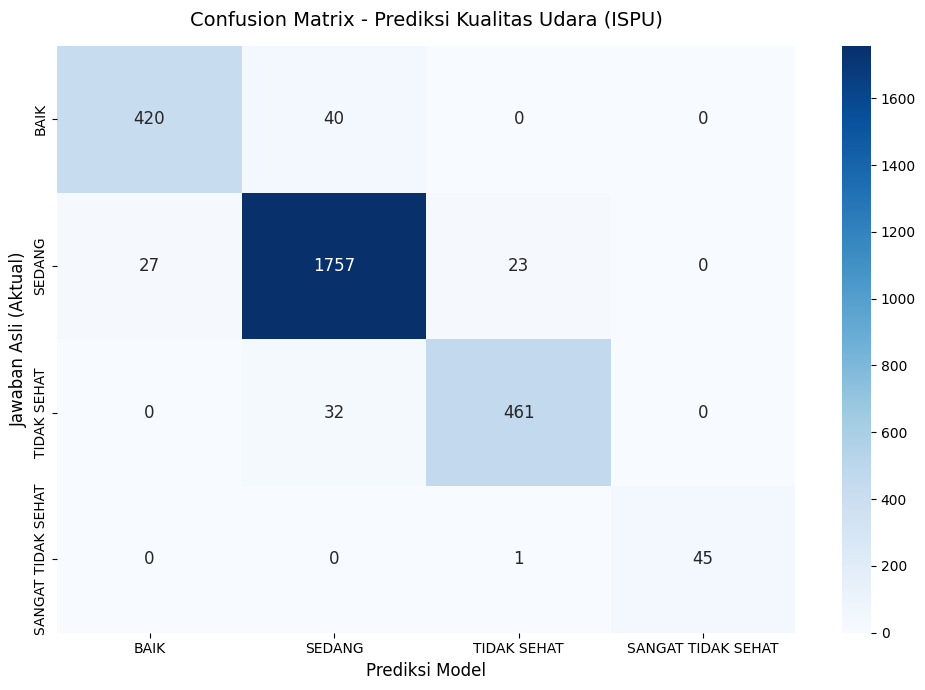

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
import joblib

print("Visualisasi confusion matrix")

# 1. Membuat Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))

# Menggunakan Seaborn Heatmap untuk pewarnaan
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names,
            annot_kws={"size": 12}) # Perbesar angka di dalam kotak

plt.title('Confusion Matrix - Prediksi Kualitas Udara (ISPU)', fontsize=14, pad=15)
plt.xlabel('Prediksi Model', fontsize=12)
plt.ylabel('Jawaban Asli (Aktual)', fontsize=12)
plt.tight_layout()

# Simpan gambarnya ke dalam folder yang sama dengan skrip ini
nama_file_gambar = 'confusion_matrix.png'
plt.savefig(nama_file_gambar, dpi=300)
print(f"Confusion matrix disimpan: '{nama_file_gambar}'")

print("\nCross validation (5-fold)")

# 2. Cross Validation
# Kita melipat data 5 kali (cv=5) untuk menguji kestabilan model di berbagai skenario pemotongan data
print("Proses cross validation...")
scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')

print(f"Skor per fold: {np.round(scores * 100, 2)}")
print(f"Rata-rata akurasi: {scores.mean() * 100:.2f}%")
print(f"Standar deviasi: {scores.std():.4f}")

print("\nSimpan model")

# 3. Export Model ke file .pkl
nama_file_model = 'model_ispu_randomforest.pkl'
joblib.dump(rf_model, nama_file_model)
print(f"Model disimpan: '{nama_file_model}'")
print("Model siap digunakan.")